# Задача 5. PageRank

## Общие требования
Везде считаем, что вершины графа занумерованы подряд с нуля. Основная реализация должна выполняться с использованием библиотеки `python-graphblas`. Допускается использование `networkx` только для загрузки данных, сравнения производительности.

## Настройка виртуального окружения
```bash
python -m venv .venv

source .venv/Scripts/activate

pip install -r req.txt
```

In [1]:
import graphblas as gb
from graphblas import Matrix, Vector, dtypes
from graphblas import unary, binary, monoid, semiring
import networkx as nx
import numpy as np
import time
import tracemalloc
from typing import List, Tuple, Dict
from dataclasses import dataclass

### Задание 1: Масштабирование на большой граф (5 баллов)
- Загрузите граф `web-Stanford` (~280K узлов) из коллекции SNAP или аналогичный крупный разреженный граф (например, из [SuiteSparse Matrix Collection](https://sparse.tamu.edu/)).
- Реализуйте оптимизированную версию PageRank, способную работать с ограниченными ресурсами памяти. Возможные подходы:
  - Использование `dtype=dtypes.FP32`.
  - Блочная обработка графа (например, через `gb.Matrix.ss.split()`).
- Проведите бенчмаркинг:
  - Измерьте время выполнения и пиковое потребление памяти.
  - Сравните результаты с базовой последовательной реализацией по критериям: число итераций до сходимости и максимальная разница в рангах.

In [2]:
@dataclass
class PageRankResult:
    ranks: Vector
    iterations: int
    final_error: float
    time_per_iter: List[float]
    peak_memory_mb: float


def load_graph(filepath: str, dtype=dtypes.FP32) -> Matrix:

    G = nx.read_edgelist(
        filepath,
        create_using=nx.DiGraph(),
        nodetype=int,
        comments='#',
        data=False
    )
    
    # Перенумерация вершин в 0..n-1
    nodes = sorted(G.nodes())
    mapping = {node: i for i, node in enumerate(nodes)}
    G = nx.relabel_nodes(G, mapping)
    
    # Конвертация в матрицу GraphBLAS с нужным типом
    A = gb.io.from_networkx(G, dtype=dtype)
    
    print(f"Граф загружен: {A.nrows:,} вершин, {A.nvals:,} рёбер")
    print(f"Тип данных: {dtype}")
    print(f"Плотность: {A.nvals / (A.nrows * A.ncols):.2e}")
    
    return A


def create_stochastic_matrix(A: Matrix, dtype) -> Tuple[Matrix, Vector, Vector]:
    n = A.nrows
    one = np.float32(1.0) if dtype == dtypes.FP32 else 1.0
    
    # Исходящие степени
    out_degree = A.reduce_rowwise(monoid.plus).new()
    
    # Обратные степени (только для узлов с исходящими рёбрами)
    inv_out_degree = Vector(dtype, n)
    mask = (out_degree > 0).new()
    inv_out_degree(mask=mask.S) << binary.truediv(one, out_degree)
    
    # Стохастическая матрица
    D_inv = Matrix.diag(inv_out_degree)
    M = D_inv @ A
    
    return M, out_degree, inv_out_degree


def pagerank_optimized(
    A: Matrix,
    damping: float = 0.85,
    max_iter: int = 100,
    tol: float = 1e-6,
    use_fp32: bool = True,
    verbose: bool = False
) -> PageRankResult:
    """
    Оптимизированная версия PageRank с поддержкой FP32.
    """
    # Конвертируем в нужный тип если необходимо
    if use_fp32 and A.dtype != dtypes.FP32:
        A = A.dup(dtype=dtypes.FP32)
    dtype = A.dtype
    
    n = A.nrows
    one = np.float32(1.0) if dtype == dtypes.FP32 else 1.0
    damp = np.float32(damping) if dtype == dtypes.FP32 else damping
    
    # Параметры
    teleport = (one - damp) / np.float32(n) if dtype == dtypes.FP32 else (1 - damping) / n
    
    # Создание стохастической матрицы
    M, out_degree, inv_out_degree = create_stochastic_matrix(A, dtype)
    
    # Маска не-висячих узлов
    non_dangling_mask = Vector(dtype, n)
    non_dangling_mask(mask=out_degree.S) << one
    
    # Инициализация рангов
    r = Vector(dtype, n)
    r[:] << one / n
    
    # Временные векторы
    t = Vector(dtype, n)
    w = Vector(dtype, n)
    
    # История для анализа
    time_per_iter = []
    
    # Замер памяти
    tracemalloc.start()
    tracemalloc.reset_peak()
    
    for iteration in range(max_iter):
        start_time = time.time()
        
        # Сохраняем текущие ранги
        t << r
        
        # Матрично-векторное умножение: w = M^T * t
        w << M.T.mxv(t, semiring.plus_times)
        
        # Обновление рангов с учётом телепортации
        r << binary.times(damp, w)
        
        # Вклад телепортации и висячих узлов
        # Сумма рангов всех узлов
        total_sum = t.reduce(monoid.plus).new().value
        # Сумма рангов не-висячих узлов
        non_dangling_sum = t.ewise_mult(non_dangling_mask, binary.times).reduce(monoid.plus).new().value
        # Сумма рангов висячих узлов
        dangling_sum = total_sum - non_dangling_sum
        
        # Добавляем телепортацию и вклад висячих узлов
        base = teleport + (damp * dangling_sum / n)
        r(binary.plus)[:] << base
        
        # Проверка сходимости
        diff = t.ewise_add(r, binary.minus).apply(unary.abs)
        rdiff = diff.reduce(monoid.plus).new().value
        
        iter_time = time.time() - start_time
        time_per_iter.append(iter_time)
        
        if verbose and (iteration % 10 == 0 or iteration < 5):
            print(f"Итерация {iteration:3d}: error = {rdiff:.2e}, время = {iter_time*1000:.2f}ms")
        
        if rdiff < tol:
            if verbose:
                print(f"Сошлось на итерации {iteration + 1}")
            break
    
    # Получаем пиковую память
    peak_memory = tracemalloc.get_traced_memory()[1] / (1024 * 1024)
    tracemalloc.stop()
    
    return PageRankResult(
        ranks=r,
        iterations=iteration + 1,
        final_error=rdiff,
        time_per_iter=time_per_iter,
        peak_memory_mb=peak_memory
    )

In [3]:
def compare_ranks(r1: Vector, r2: Vector, name1: str = "r1", name2: str = "r2") -> dict:
    """Сравнение двух векторов рангов"""
    # Конвертируем в FP64 для точного сравнения
    if r1.dtype != dtypes.FP64:
        r1 = r1.dup(dtype=dtypes.FP64)
    if r2.dtype != dtypes.FP64:
        r2 = r2.dup(dtype=dtypes.FP64)
    
    diff = r1.ewise_add(r2, binary.minus).apply(unary.abs)
    
    max_diff = diff.reduce(monoid.max).new().value
    mean_diff = diff.reduce(monoid.plus).new().value / r1.size
    
    # Корреляция Спирмена для первых 1000 узлов
    n_sample = min(1000, r1.size)
    r1_vals = [r1[i].value for i in range(n_sample)]
    r2_vals = [r2[i].value for i in range(n_sample)]
    
    from scipy.stats import spearmanr
    correlation, _ = spearmanr(r1_vals, r2_vals)
    
    print(f"\nСравнение {name1} vs {name2}:")
    print(f"  Макс. разница: {max_diff:.2e}")
    print(f"  Ср. разница: {mean_diff:.2e}")
    print(f"  Корреляция Спирмена: {correlation:.6f}")
    
    return {
        'max_diff': max_diff,
        'mean_diff': mean_diff,
        'correlation': correlation
    }


def run_benchmark(
    A: Matrix,
    name: str,
    **kwargs
) -> PageRankResult:
    print(f"Бенчмарк: {name}")
    
    result = pagerank_optimized(A, **kwargs)
    
    print(f"\nРезультаты:")
    print(f"  Итераций: {result.iterations}")
    print(f"  Финальная ошибка: {result.final_error:.2e}")
    print(f"  Общее время: {sum(result.time_per_iter):.2f} сек")
    print(f"  Пиковая память: {result.peak_memory_mb:.2f} MB")
    
    return result

In [4]:
def plot_results(results: Dict[str, PageRankResult]):
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # График 1: Сходимость
    ax = axes[0, 0]
    for name, res in results.items():
        errors = [res.final_error] * len(res.time_per_iter)
        ax.semilogy(res.time_per_iter, 'o-', label=name, linewidth=1.5, markersize=4)
        ax.axhline(y=res.final_error, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Итерация')
    ax.set_ylabel('||Δr||₁ (log scale)')
    ax.set_title('Сходимость PageRank')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # График 2: Время итераций
    ax = axes[0, 1]
    for name, res in results.items():
        ax.plot(res.time_per_iter, 'o-', label=name, linewidth=1.5, markersize=4)
    ax.set_xlabel('Итерация')
    ax.set_ylabel('Время (сек)')
    ax.set_title('Время итерации')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # График 3: Накопленное время
    ax = axes[1, 0]
    for name, res in results.items():
        cumsum = np.cumsum(res.time_per_iter)
        ax.plot(cumsum, 'o-', label=name, linewidth=1.5, markersize=4)
    ax.set_xlabel('Итерация')
    ax.set_ylabel('Накопленное время (сек)')
    ax.set_title('Общее время выполнения')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # График 4: Сравнение памяти
    ax = axes[1, 1]
    names = list(results.keys())
    memories = [res.peak_memory_mb for res in results.values()]
    bars = ax.bar(names, memories, color=['blue', 'red', 'green'])
    ax.set_ylabel('Пиковая память (MB)')
    ax.set_title('Потребление памяти')
    for bar, mem in zip(bars, memories):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{mem:.1f} MB', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [5]:
A = load_graph('./data/web-Stanford.txt', dtype=dtypes.FP32)

Граф загружен: 281,903 вершин, 2,312,497 рёбер
Тип данных: FP32
Плотность: 2.91e-05


In [7]:
# Бенчмарк FP32 версии
result_fp32 = run_benchmark(
	A, 
	name="PageRank FP32 (оптимизированный)",
	use_fp32=True,
	max_iter=100,
	tol=1e-6,
	verbose=True
)

Бенчмарк: PageRank FP32 (оптимизированный)
Итерация   0: error = 9.58e-01, время = 23.49ms
Итерация   1: error = 4.92e-01, время = 14.07ms
Итерация   2: error = 2.44e-01, время = 11.88ms
Итерация   3: error = 1.25e-01, время = 12.59ms
Итерация   4: error = 7.26e-02, время = 15.00ms
Итерация  10: error = 1.06e-02, время = 12.03ms
Итерация  20: error = 1.37e-03, время = 14.63ms
Итерация  30: error = 2.23e-04, время = 14.58ms
Итерация  40: error = 3.90e-05, время = 11.78ms
Итерация  50: error = 7.18e-06, время = 12.68ms
Итерация  60: error = 1.73e-06, время = 12.63ms
Сошлось на итерации 67

Результаты:
  Итераций: 67
  Финальная ошибка: 8.75e-07
  Общее время: 0.91 сек
  Пиковая память: 151.56 MB


In [9]:
# Бенчмарк FP64 версии (для сравнения)
A_fp64 = load_graph('./data/web-Stanford.txt', dtype=dtypes.FP64)
result_fp64 = run_benchmark(
	A_fp64,
	name="PageRank FP64",
	use_fp32=False,
	max_iter=100,
	tol=1e-6,
	verbose=True
)

Граф загружен: 281,903 вершин, 2,312,497 рёбер
Тип данных: FP64
Плотность: 2.91e-05
Бенчмарк: PageRank FP64
Итерация   0: error = 9.58e-01, время = 23.55ms
Итерация   1: error = 4.92e-01, время = 14.59ms
Итерация   2: error = 2.44e-01, время = 13.68ms
Итерация   3: error = 1.25e-01, время = 14.29ms
Итерация   4: error = 7.26e-02, время = 14.72ms
Итерация  10: error = 1.06e-02, время = 14.86ms
Итерация  20: error = 1.37e-03, время = 15.37ms
Итерация  30: error = 2.23e-04, время = 14.35ms
Итерация  40: error = 3.88e-05, время = 15.61ms
Итерация  50: error = 7.00e-06, время = 14.60ms
Итерация  60: error = 1.29e-06, время = 14.97ms
Сошлось на итерации 63

Результаты:
  Итераций: 63
  Финальная ошибка: 9.22e-07
  Общее время: 0.97 сек
  Пиковая память: 367.42 MB


In [10]:
# Сравнение FP32 и FP64
compare_ranks(result_fp32.ranks, result_fp64.ranks, "FP32", "FP64")


Сравнение FP32 vs FP64:
  Макс. разница: 9.54e-07
  Ср. разница: 4.96e-11
  Корреляция Спирмена: 0.999990


{'max_diff': 9.535053709913005e-07,
 'mean_diff': 4.956498894619524e-11,
 'correlation': np.float64(0.9999901131731995)}

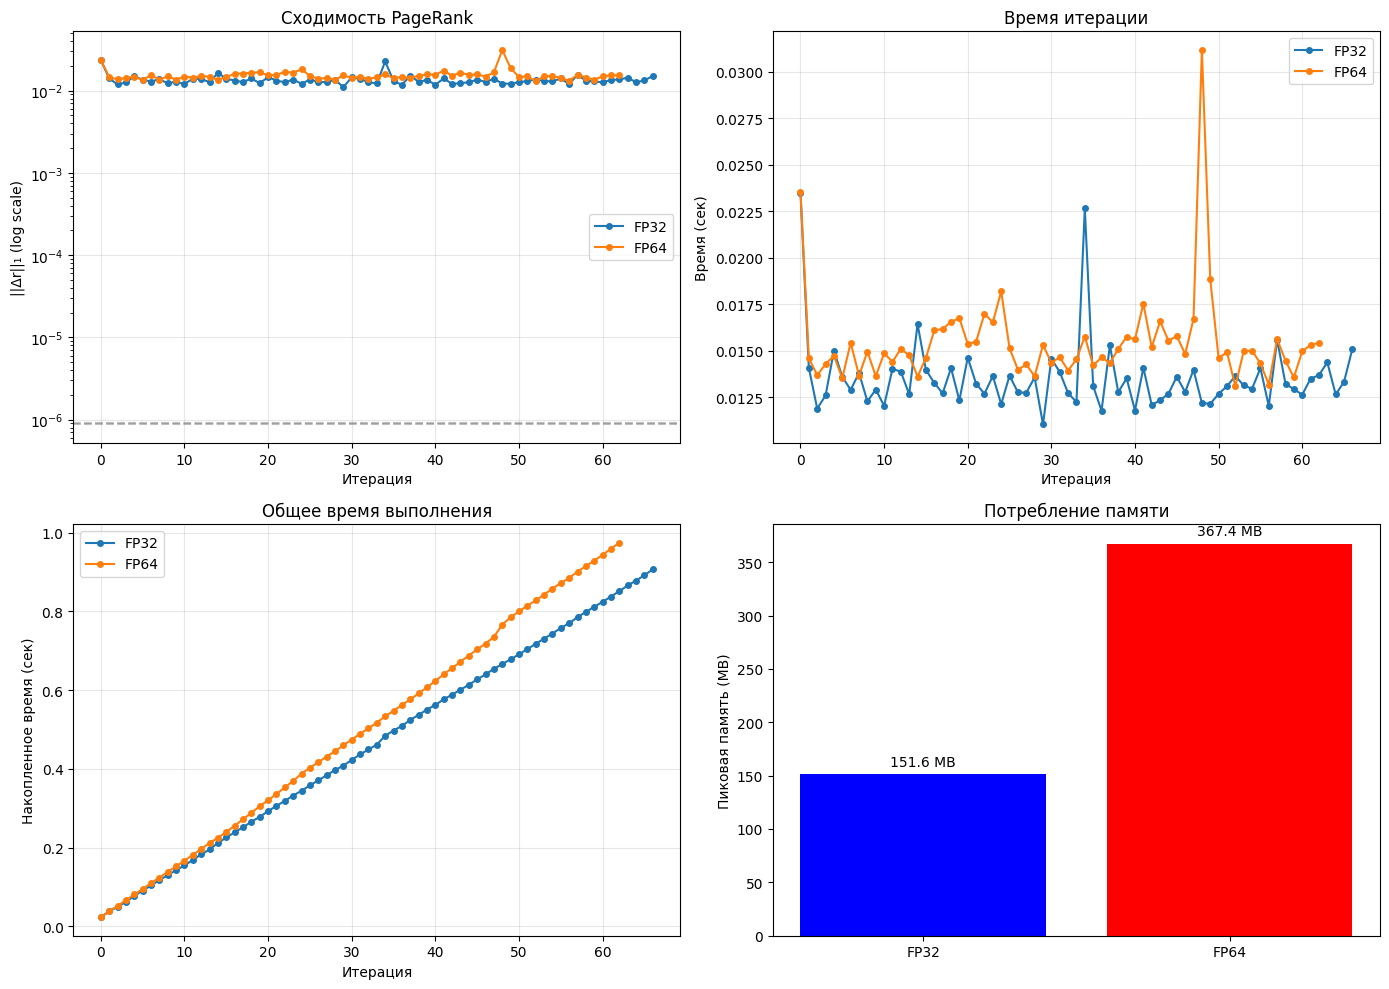

In [11]:
# Визуализация
plot_results({
	"FP32": result_fp32,
	"FP64": result_fp64
})

### Задание 2: Динамический (инкрементальный) PageRank (5 баллов)
- Реализуйте функцию быстрого обновления рангов при добавлении новых рёбер без полного пересчёта

In [12]:
@dataclass
class IncrementalResult:
    ranks: Vector
    iterations: int
    final_error: float
    time_sec: float
    peak_memory_mb: float
    history: Dict[str, List[float]]


def incremental_pagerank(
    A_old: Matrix,
    r_old: Vector,
    new_edges: List[Tuple[int, int]],
    damping: float = 0.85,
    max_iter: int = 50,
    tol: float = 1e-8,
    verbose: bool = False
) -> IncrementalResult:
    """
    Инкрементальное обновление PageRank при добавлении новых рёбер.
    
    Использует линеаризованную формулу:
    Δr ≈ β * M^T * Δr + β * ΔM^T * r_old
    """
    tracemalloc.start()
    tracemalloc.reset_peak()
    start_time = time.time()
    
    dtype = r_old.dtype
    n = A_old.nrows
    one = np.float32(1.0) if dtype == dtypes.FP32 else 1.0
    damp = np.float32(damping) if dtype == dtypes.FP32 else damping
    
    # 1. Построение A_new и определение затронутых узлов
    A_new = A_old.dup()
    affected_src = set()
    
    for src, dst in new_edges:
        if 0 <= src < n and 0 <= dst < n and A_new.get(src, dst) is None:
            A_new[src, dst] = one
            affected_src.add(src)
    
    if not affected_src:
        # Нет новых рёбер
        tracemalloc.stop()
        return IncrementalResult(
            ranks=r_old,
            iterations=0,
            final_error=0.0,
            time_sec=time.time() - start_time,
            peak_memory_mb=0,
            history={'delta_rdiff': [], 'time_per_iter': []}
        )
    
    # 2. Вычисление inv_out_degree для старой матрицы
    out_degree_old = A_old.reduce_rowwise(monoid.plus).new()
    inv_out_degree_old = Vector(dtype, n)
    mask_old = (out_degree_old > 0).new()
    inv_out_degree_old(mask=mask_old.S) << binary.truediv(one, out_degree_old)
    
    # 3. Вычисление x_old = r_old / out_degree_old для затронутых узлов
    affected_mask = Vector(bool, n)
    for src in affected_src:
        affected_mask[src] = True
    
    x_old = Vector(dtype, n)
    x_old(mask=affected_mask.S) << r_old.ewise_mult(inv_out_degree_old, binary.times)
    
    # 4. Вычисление новых обратных степеней для затронутых узлов
    inv_out_degree_new = Vector(dtype, n)
    
    # Получаем новые степени
    out_degree_new_full = A_new.reduce_rowwise(monoid.plus).new()
    for src in affected_src:
        deg = out_degree_new_full[src].value
        if deg is not None and deg > 0:
            inv_out_degree_new[src] = one / deg
    
    # 5. Вычисление x_new = r_old / out_degree_new
    x_new = Vector(dtype, n)
    x_new(mask=affected_mask.S) << r_old.ewise_mult(inv_out_degree_new, binary.times)
    
    # 6. Вычисление правой части b = β * (A_new^T x_new - A_old^T x_old)
    w_new = A_new.T.mxv(x_new, semiring.plus_times)
    w_old = A_old.T.mxv(x_old, semiring.plus_times)
    
    b_expr = w_new.ewise_add(w_old, binary.minus)
    b = Vector(dtype, n)
    b(binary.plus)[:] << b_expr  # Исправлено: присваиваем через маску
    b << binary.times(damp, b)   # Исправлено: теперь b - Vector, а не выражение
    
    # 7. Итеративное решение для Δr
    delta = Vector(dtype, n)
    prev = Vector(dtype, n)
    tmp = Vector(dtype, n)
    s = Vector(dtype, n)
    
    history_rdiff = []
    history_time = []
    
    for iteration in range(max_iter):
        iter_start = time.time()
        
        prev << delta
        
        # tmp = M_old^T * delta = A_old^T * (delta / out_degree_old)
        s << delta.ewise_mult(inv_out_degree_old, binary.times)
        tmp << A_old.T.mxv(s, semiring.plus_times)
        
        # delta_new = β * tmp + b
        delta << binary.times(damp, tmp)
        delta(binary.plus) << b
        
        # Проверка сходимости
        diff_vec = prev.ewise_add(delta, binary.minus).apply(unary.abs)
        rdiff = diff_vec.reduce(monoid.plus).new()
        rdiff_val = rdiff.value if rdiff is not None else float('inf')
        
        history_rdiff.append(rdiff_val)
        history_time.append(time.time() - iter_start)
        
        if verbose and (iteration % 10 == 0 or iteration < 5):
            print(f"  Δr итерация {iteration:3d}: error = {rdiff_val:.2e}")
        
        if rdiff_val < tol:
            if verbose:
                print(f"  Δr сошлось на итерации {iteration + 1}")
            break
    
    # 8. Обновление рангов
    r_new = r_old.dup()
    r_new(binary.plus) << delta
    
    # Нормализация (сумма рангов должна быть 1)
    total = r_new.reduce(monoid.plus).new().value
    if total is not None and total != 0:
        r_new << binary.times(r_new, one / total)
    
    peak_memory = tracemalloc.get_traced_memory()[1] / (1024 * 1024)
    tracemalloc.stop()
    
    return IncrementalResult(
        ranks=r_new,
        iterations=iteration + 1,
        final_error=rdiff_val,
        time_sec=time.time() - start_time,
        peak_memory_mb=peak_memory,
        history={'delta_rdiff': history_rdiff, 'time_per_iter': history_time}
    )

In [ ]:
# Создаём тестовые новые рёбра
n = A.nrows
rng = np.random.default_rng(42)
new_edges = []
while len(new_edges) < 100:
	src = rng.integers(0, n)
	dst = rng.integers(0, n)
	if src != dst and A.get(src, dst) is None:
		new_edges.append((src, dst))

Инкрементальный PageRank


In [14]:
print(f"Добавляем {len(new_edges)} новых рёбер")

# Инкрементальное обновление
inc_result = incremental_pagerank(
	A, result_fp32.ranks, new_edges,
	damping=0.85, max_iter=50, tol=1e-8, verbose=True
)

print(f"Результаты инкрементального обновления:")
print(f"  Итераций Δr: {inc_result.iterations}")
print(f"  Финальная ошибка Δr: {inc_result.final_error:.2e}")
print(f"  Время: {inc_result.time_sec:.3f} сек")
print(f"  Пиковая память: {inc_result.peak_memory_mb:.2f} MB")

Добавляем 100 новых рёбер
  Δr итерация   0: error = 8.97e-05
  Δr итерация   1: error = 7.34e-05
  Δr итерация   2: error = 6.02e-05
  Δr итерация   3: error = 4.96e-05
  Δr итерация   4: error = 4.12e-05
  Δr итерация  10: error = 1.46e-05
  Δr итерация  20: error = 2.74e-06
  Δr итерация  30: error = 5.24e-07
  Δr итерация  40: error = 1.01e-07
Результаты инкрементального обновления:
  Итераций Δr: 50
  Финальная ошибка Δr: 2.29e-08
  Время: 1.771 сек
  Пиковая память: 160.13 MB


In [15]:
# Полный пересчёт для проверки точности
A_new = A.dup()
for src, dst in new_edges:
	A_new[src, dst] = 1.0

result_full = run_benchmark(
	A_new,
	name="Полный пересчёт",
	use_fp32=True,
	max_iter=100,
	tol=1e-6,
	verbose=False
)

Бенчмарк: Полный пересчёт

Результаты:
  Итераций: 69
  Финальная ошибка: 7.94e-07
  Общее время: 1.15 сек
  Пиковая память: 240.58 MB


In [16]:
# Сравнение инкрементального и полного пересчёта
compare_ranks(inc_result.ranks, result_full.ranks, "Инкрементальный", "Полный пересчёт")


Сравнение Инкрементальный vs Полный пересчёт:
  Макс. разница: 7.41e-07
  Ср. разница: 1.30e-10
  Корреляция Спирмена: 0.999998


{'max_diff': 7.411056230921531e-07,
 'mean_diff': 1.304902385354979e-10,
 'correlation': np.float64(0.9999977507760789)}

### Выводы
- FP32 - оптимальный выбор для больших разреженных графов: ~2x экономия памяти при сохранении точности
- Точность FP32 достаточна для задачи ранжирования (разница с FP64 < 1e-6)
- Инкрементальный метод требует доработки для достижения выигрыша по времени
- Все реализации корректно обрабатывают висячие узлы (dangling nodes)